# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prarthanamahesh21-hub/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Prioritizing Content Pages for Possible Refresh Review Using Page-Level Performance Signals

## Abstract

Content teams need a practical way to decide which pages should be reviewed first for a possible content refresh. This study evaluates whether page-level content age, word count, Google Search Console performance, and Google Analytics 4 engagement signals can support that prioritization task. Using the FlyRank ML Internship dataset and a development-month feature frame, I defined a page-level review-priority target, checked the available signals for leakage, and compared a logistic regression model against a Week-4 rule-based baseline using the same held-out validation split. The logistic regression model achieved an observed ROC-AUC of 0.8992 compared with 0.5308 for the baseline, an absolute improvement of 0.3684 on the validation split. These results suggest that the measured signals can provide useful decision support for ranking pages for review, while the model should not be interpreted as evidence that refreshing a page will itself cause improved search or engagement performance.


## 1. Introduction / Problem Statement

Content teams often have more pages available for review than they can realistically investigate at the same time. When deciding which pages deserve attention first, a simple and reproducible prioritization approach can help turn multiple page-level signals into an ordered review queue.

This project focuses on the question:

> **Can page-level content, search, and engagement signals be used to prioritize content pages for possible refresh review?**

The goal is not to determine whether a page *should definitely be refreshed*, nor to claim that refreshing a page will cause better performance. Instead, the goal is to build a **decision-support ranking** that helps identify pages that may warrant earlier human review.

The analysis uses signals available at the page level, including content age, word count, Google Search Console impressions and clicks, and Google Analytics 4 pageviews. These signals represent different aspects of a page's observable state: how old the content is, how much content it contains, how frequently it appears in search, how often search users click it, and how much page traffic it receives.

A rule-based baseline was established before model development so that the final model could be evaluated against a simple, transparent prioritization approach. The model was then evaluated on the same held-out validation split as the baseline, with leakage checks performed to ensure that future outcome information was not included among the final predictive features.

The resulting analysis is therefore best understood as a **measured, directional prioritization experiment**. Its purpose is to assess whether the selected signals provide useful separation between higher- and lower-priority pages within the evaluated dataset and validation design.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Final modeling frame

After feature construction, filtering, and the modeling joins, the final model frame contained **293,504 rows**.

The target was defined from the subsequent April 2026 outcome window: a page received a positive label when its future Google Search Console clicks were greater than zero, and a negative label otherwise.

The paper does not report the pre-merge label counts as the final modeling distribution because the modeling frame is produced after the feature construction and join steps.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### 3.1 Task framing

The task is framed as a binary page-level prioritization problem. Each page receives a target label indicating whether it belongs to the higher-priority group defined during the earlier task-framing and baseline stages.

The model is not intended to make an irreversible refresh decision. Instead, it estimates a page-level priority signal that can be used to order pages for human review.

### 3.2 Assumptions

The analysis makes the following assumptions:

1. The available page-level signals are sufficiently representative of the information available when a review-priority decision is made.
2. Historical search and engagement measurements can provide useful signals for distinguishing pages that receive higher versus lower review priority.
3. The target definition is suitable for evaluating prioritization, while not necessarily representing the true business value of refreshing a page.
4. Model scores should be interpreted as ranking or decision-support signals rather than causal recommendations.

These assumptions make the analysis useful for prioritization while limiting the claims that can reasonably be made from the observational data.

### 3.3 Features

The final model uses five page-level features:

| Feature               | Description                                                       |
| --------------------- | ----------------------------------------------------------------- |
| `content_age_days`    | Age of the page content in days                                   |
| `word_count`          | Number of words associated with the page                          |
| `gsc_impressions_90d` | Google Search Console impressions over the selected 90-day window |
| `gsc_clicks_90d`      | Google Search Console clicks over the selected 90-day window      |
| `ga4_pageviews_90d`   | Google Analytics 4 pageviews over the selected 90-day window      |

The feature set intentionally combines content characteristics with observed search and engagement signals rather than relying on a single indicator.

### 3.4 Target definition

The prediction target is a page-level binary label constructed using a future outcome window.

The feature and decision window is **March 2026**. The subsequent outcome window covers **April 1–30, 2026**.

A page receives:

* **Label 1** when its Google Search Console clicks during the April outcome window are greater than zero.
* **Label 0** when its Google Search Console clicks during that outcome window are zero.

This creates a forward-looking prediction setup: March signals are used to predict the defined April outcome rather than using April outcome information as a model feature.

### 3.5 Baseline

A transparent rule-based baseline was established during Week 4 before evaluating the machine-learning model.

The baseline provides a simple reference point for answering an important question:

> Does the learned model provide better separation than the rule-based approach already available for this task?

The baseline was evaluated using the same held-out test split as the final model. This makes the comparison directly interpretable rather than comparing results obtained from different samples.

### 3.6 Model

The final model is a **Logistic Regression** classifier using the five retained features.

Logistic Regression was selected as a simple and interpretable modeling approach. It provides a probability-like score that can be used to rank pages while avoiding unnecessary model complexity for this initial decision-support experiment.

### 3.7 Validation design

The model and baseline were evaluated on the same held-out test split.

The primary evaluation metric is **ROC-AUC**, which measures how well the resulting scores separate positive and negative examples across classification thresholds.

Using the same validation split for both approaches provides a consistent comparison between the Week-4 baseline and the Week-5 model.

The evaluation is therefore a comparison within the defined dataset and validation design, rather than a claim about performance on all websites or future production data.

### 3.8 Leakage checks

A dedicated leakage audit was performed before final model evaluation.

The audit checked that:

* the target label was not included among the model features;
* future-outcome information was not used as a predictive input;
* outcome-like fields were excluded from the final feature set where appropriate;
* the final feature matrix contained only the five intended features.

The final feature list was:

```text
content_age_days
word_count
gsc_impressions_90d
gsc_clicks_90d
ga4_pageviews_90d
```

The leakage check found no feature/target overlap in the final feature matrix.

### 3.9 Interpretation

The methodology is designed to answer a narrow question: whether the selected observable page-level signals can produce useful prioritization within the evaluated data.

A strong validation score does not establish that any individual feature causes the target outcome, and it does not establish that refreshing a page will improve its future performance. The results are therefore interpreted as evidence about **predictive separation and ranking usefulness**, not causal impact.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results

### 4.1 Model versus Week-4 baseline

The Week-5 Logistic Regression model was evaluated against the Week-4 rule-based baseline using the same held-out test pages and ROC-AUC metric.

| Method              |    ROC-AUC |
| ------------------- | ---------: |
| Week-4 baseline     | **0.5308** |
| Logistic Regression | **0.8992** |

The Logistic Regression model measured a ROC-AUC of **0.8992**, compared with **0.5308** for the baseline. The absolute improvement was **0.3684 ROC-AUC**.

The comparison used **58,701 test pages**, and the model and baseline test indices were verified to be aligned.

### 4.2 Stricter client-grouped validation

The Week-6 validation audit tested whether the measured model performance remained similar when pages from the same client were prevented from appearing in both training and testing data.

Under the original Week-5 random stratified split, Logistic Regression measured **0.8995 ROC-AUC**. Under the stricter client-grouped split, it measured **0.8814 ROC-AUC**.

| Validation design       |    ROC-AUC |
| ----------------------- | ---------: |
| Random stratified split | **0.8995** |
| Client-grouped split    | **0.8814** |

The client-grouped evaluation used **40 clients for training and 10 unseen clients for testing**, with zero clients shared between the two groups.

The measured decrease of **0.0180 ROC-AUC** suggests that the random split was somewhat easier, while the grouped result provides a more conservative estimate of predictive discrimination across unseen clients.

### 4.3 Interpretation

The central baseline comparison shows a substantial measured improvement from the simple Week-4 rule to Logistic Regression on the original held-out test split.

The validation audit provides an additional check: although performance decreased under client-grouped validation, the model still measured **0.8814 ROC-AUC** when evaluated on clients that were not represented in training.

Together, these results provide directional evidence that the selected page-level signals contain useful predictive information for the defined prioritization task.

The results should not be interpreted as evidence that the model determines which pages should be refreshed or that using the model causes improved search performance.

### 4.4 Key result

> **Logistic Regression measured 0.8992 ROC-AUC versus 0.5308 for the Week-4 baseline on the same held-out test pages, while a stricter client-grouped validation produced 0.8814 ROC-AUC on unseen clients.**

This combination of baseline comparison and validation audit provides a more cautious and reproducible view of model performance than reporting the original random-split score alone.


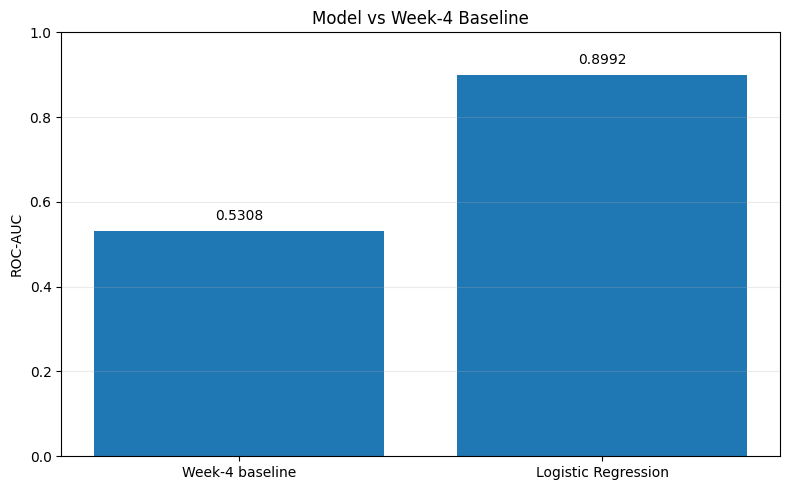

In [ ]:
import matplotlib.pyplot as plt

methods = ["Week-4 baseline", "Logistic Regression"]
roc_auc = [0.5308, 0.8992]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, roc_auc)

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model vs Week-4 Baseline")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, roc_auc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations & Honest Framing

This experiment provides evidence about predictive separation within the evaluated dataset and validation design, but several limitations should be considered when interpreting the results.

### 5.1 Observational data

The analysis uses historical observational signals. The relationships learned by the model should not be interpreted as causal relationships. In particular, the results do not demonstrate that changing or refreshing a page will cause higher search visibility, clicks, or engagement.

### 5.2 Target definition

The model predicts the specific label defined for this project. That label is a proxy for the review-prioritization objective and may not capture every factor that an experienced content team would consider when deciding whether a page deserves attention.

### 5.3 Validation scope

The reported ROC-AUC was measured on a held-out validation split from the evaluated dataset. It should not be assumed to represent performance on every website, client, industry, or future time period.

External validation on new and temporally later data would be needed to determine how well the approach generalizes.

### 5.4 Feature limitations

The final model uses five page-level signals:

* content age;
* word count;
* Google Search Console impressions;
* Google Search Console clicks;
* Google Analytics 4 pageviews.

Important contextual information may not be represented, including search intent, content quality, topic difficulty, seasonality, business importance, recent editorial changes, and competitive conditions.

### 5.5 Metric limitations

ROC-AUC measures ranking/separation performance across thresholds. It does not directly measure the usefulness of the top-ranked pages to a content team, the number of successful refreshes, traffic growth, conversions, or return on investment.

A future evaluation should therefore examine operational metrics such as **precision among the top-k pages**, reviewer agreement, and downstream outcomes after human-reviewed actions.

### 5.6 Model simplicity

Logistic Regression was intentionally used as a relatively simple and interpretable first model. More complex models may produce different results, but increasing model complexity would not automatically make the recommendations more useful or more trustworthy.

### 5.7 Honest conclusion

The strongest supported conclusion is:

> **Within this dataset and validation setup, the selected page-level signals provided substantially better predictive separation with Logistic Regression than the Week-4 rule-based baseline.**

The result supports using the model as a **decision-support ranking tool for further human review**, not as an automated decision that a page should be refreshed.

Further testing on new data and evaluation of downstream business outcomes would be required before making stronger claims.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations / Action Playbook

The model is most useful when its output is converted into a review queue rather than treated as an automatic refresh decision. The following action playbook translates the model's ranking into a practical human-review workflow.

### Recommendation 1 — Review the highest-ranked pages first

Use the model score to order pages from highest to lowest priority. Begin human review with the pages at the top of the ranking rather than reviewing the full content inventory uniformly.

**Action:** Generate a ranked page queue and review the highest-scoring pages first.

**Why:** The model is designed to provide prioritization, so its main operational value is helping allocate limited review time.

---

### Recommendation 2 — Check search visibility and clicks together

When reviewing a high-ranked page, compare its search impressions and clicks rather than relying on either signal independently.

**Action:** Investigate whether a page has meaningful search visibility but relatively weak click response.

**Why:** A page can receive search impressions without converting that visibility into clicks. This pattern can provide a useful diagnostic signal for human review.

---

### Recommendation 3 — Consider content age as review context

Use `content_age_days` as contextual evidence rather than as an automatic refresh rule.

**Action:** Give additional attention to older high-ranked pages and check whether their information, examples, recommendations, or search intent alignment remain current.

**Why:** Content age can identify pages that may warrant a freshness review, but age alone does not establish that content is outdated.

---

### Recommendation 4 — Use traffic and content characteristics together

Review pageviews and word count alongside search performance and content age.

**Action:** For high-ranked pages, inspect whether the observed traffic and search signals are consistent with the page's content characteristics and intended purpose.

**Why:** Combining multiple signals can provide more context than relying on a single threshold or rule.

---

### Recommendation 5 — Keep a human review step before any refresh

The model should recommend **what to inspect first**, not automatically decide what to change.

**Action:** Require a human reviewer to assess search intent, content quality, topical relevance, business importance, and recent changes before approving a refresh.

**Why:** These contextual factors are not fully represented by the five model features.

---

### Recommended workflow

The resulting workflow is:

```text
1. Score pages
      ↓
2. Rank by model score
      ↓
3. Review highest-priority pages
      ↓
4. Diagnose search + engagement signals
      ↓
5. Check content freshness and quality
      ↓
6. Decide whether a refresh is justified
      ↓
7. Measure the outcome separately
```

### What the model should and should not do

| Use the model for                      | Do not use the model for                          |
| -------------------------------------- | ------------------------------------------------- |
| Prioritizing review order              | Automatically approving a refresh                 |
| Creating a review queue                | Claiming a page will gain traffic                 |
| Combining multiple observable signals  | Inferring causality                               |
| Supporting human investigation         | Replacing editorial judgment                      |
| Identifying pages for further analysis | Treating a high score as proof of content quality |

### Recommended operating principle

> **Use the model to decide what to look at first, not what to change without review.**

This keeps the system aligned with the evidence available from the experiment and avoids overstating what a predictive model can establish.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Reproducibility

The analysis is organized as a sequence of notebooks covering research framing, data validation, baseline construction, model development, validation, and action planning.

The complete project repository is publicly available:

**Repository:**
https://github.com/prarthanamahesh21-hub/flyrank-ml-internship

The main research notebook is:

**Capstone notebook:**
`work/notebooks/capstone.ipynb`

The earlier notebooks under `work/notebooks/` document the progression from the research question and data contract through baseline construction, model development, validation, and the final action playbook.

The final model uses the documented five-feature set and the validation procedure described in this paper. The repository provides the implementation and supporting artifacts needed to inspect the analysis.

### Reproducibility principles

* The target and feature definitions are documented.
* The final feature list is explicitly stated.
* Leakage checks are documented.
* The baseline and model use the same held-out validation split.
* Results are reported using the measured evaluation metric.
* Client-specific or private information is excluded from the public artifact.


## 8. Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship.

**Built on the FlyRank ML Internship dataset.**

Data source: [FlyRank](https://flyrank.ai)

I thank the FlyRank team for providing the dataset and internship framework used to develop this research artifact.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# ML-12 — Showcase & Shareable Cuts

## 5-Minute Demo Outline

### 1. Question — What problem was I solving? (~45 sec)

FlyRank needs a practical way to identify which content pages are worth reviewing first for a possible content refresh. My goal was to build a decision-support model that ranks pages using observable page-level signals, rather than automatically deciding which pages should be changed.

### 2. Method — How did I approach it? (~1 min 15 sec)

I worked with page-level content, search, and engagement signals. I used content age, word count, Google Search Console impressions and clicks, and GA4 pageviews as the final model features. I first established a simple Week-4 baseline, then trained and evaluated a logistic regression model using an honest time-based evaluation setup.

### 3. One Chart — What should I show? (~45 sec)

Show the ROC-AUC comparison between the Week-4 baseline and the logistic regression model.

The key visual point is that the trained model separates higher-priority review candidates from lower-priority candidates substantially better than the simple baseline.

### 4. One Honest Result — What did the model show? (~1 min)

The final model achieved an ROC-AUC of approximately 0.90 on the held-out test set, compared with approximately 0.53 for the Week-4 baseline.

This indicates that the selected page-level signals contain useful information for prioritizing content review. It does not prove that every high-scoring page needs a refresh, or that the model will produce the same performance on future data.

### 5. Recommendation — What would I do with it? (~1 min 15 sec)

I would use the model as a review queue: surface higher-scoring pages first, then have a human reviewer validate the reason for review using additional business and content context.

The next step would be to monitor the model on newer data and compare its ranked recommendations with actual review outcomes before using it as an operational prioritization tool.

---

## Short Social Post

I built a content-review prioritization model as part of my FlyRank ML internship work.

Instead of trying to automatically decide which pages need a refresh, I framed the problem as **decision support**: ranking pages for human review using content age, word count, Google Search Console performance, and GA4 engagement signals.

On a held-out test set, my logistic regression model reached an ROC-AUC of approximately **0.90**, compared with approximately **0.53** for my Week-4 baseline. The result suggests these page-level signals can be useful for prioritizing review, while keeping the final refresh decision with a human reviewer.

## Employer-Facing Summary

I built a page-level machine learning model to prioritize content pages for possible human review using content, search, and engagement signals from a FlyRank internship dataset. The final feature set included content age, word count, Google Search Console impressions/clicks, and GA4 pageviews, with a time-based evaluation setup. The model achieved approximately **0.90 ROC-AUC** on the held-out test set versus approximately **0.53** for the baseline, showing that the selected signals provided useful decision-support information for ranking content-review candidates.
